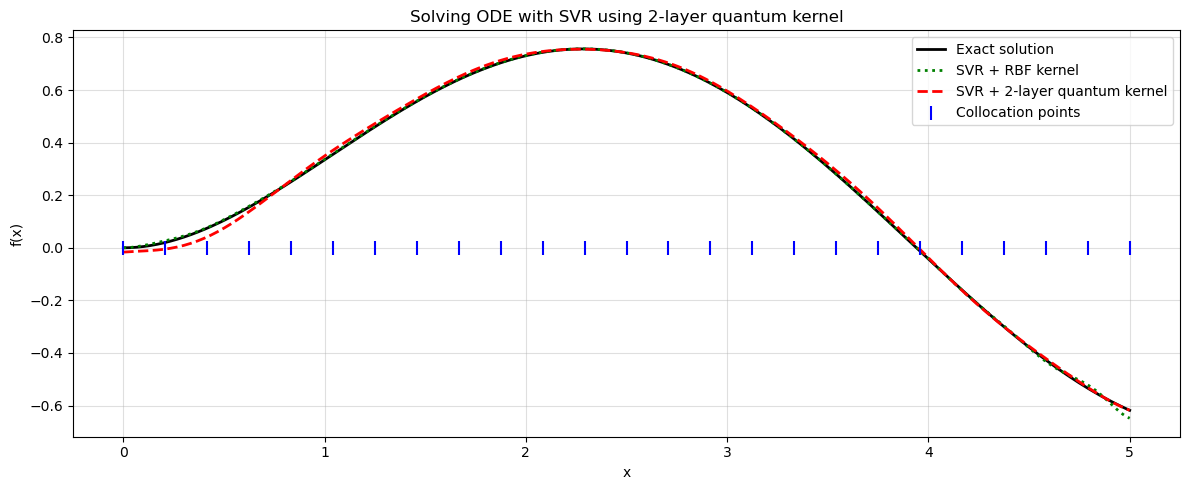

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ------------------------------------------------------------
# 1. Quantum Kernel Classes
# ------------------------------------------------------------
class QuantumKernel:
    """Base class for quantum kernels."""
    def __init__(self, n_qubits=4):
        self.n_qubits = n_qubits

    def evaluate(self, x, y):
        """Returns κ(x,y) = |<ψ(x)|ψ(y)>|^2."""
        raise NotImplementedError

class TwoLayerQuantumKernel(QuantumKernel):
    """
    2‑layer data re‑uploading quantum kernel.
    - encoding: 'product' (same angle on all qubits) or 'tower' (angle = (q+1)*x)
    """
    def __init__(self, n_qubits=4, encoding='product'):
        super().__init__(n_qubits)
        self.encoding = encoding

    def _feature_map(self, x):
        qc = QuantumCircuit(self.n_qubits)
        # Layer 1
        if self.encoding == 'tower':
            for q in range(self.n_qubits):
                qc.rx((q + 1) * x, q)
        else:  # product
            for q in range(self.n_qubits):
                qc.rx(x, q)
        # Entangling layer (linear chain)
        for q in range(self.n_qubits - 1):
            qc.cx(q, q + 1)
        # Layer 2
        if self.encoding == 'tower':
            for q in range(self.n_qubits):
                qc.rx((q + 1) * x, q)
        else:
            for q in range(self.n_qubits):
                qc.rx(x, q)
        # Second entangling layer
        for q in range(self.n_qubits - 1):
            qc.cx(q, q + 1)
        return qc

    def evaluate(self, x, y):
        psi_x = Statevector.from_instruction(self._feature_map(x))
        psi_y = Statevector.from_instruction(self._feature_map(y))
        return np.abs(np.vdot(psi_x.data, psi_y.data))**2

# ------------------------------------------------------------
# 2. Helper functions for kernel derivatives (finite differences)
# ------------------------------------------------------------
def derivative_x(kernel, x, y, eps=1e-5):
    return (kernel(x + eps, y) - kernel(x - eps, y)) / (2 * eps)

def derivative_y(kernel, x, y, eps=1e-5):
    return (kernel(x, y + eps) - kernel(x, y - eps)) / (2 * eps)

def derivative_xy(kernel, x, y, eps=1e-5):
    f_p_p = kernel(x + eps, y + eps)
    f_p_m = kernel(x + eps, y - eps)
    f_m_p = kernel(x - eps, y + eps)
    f_m_m = kernel(x - eps, y - eps)
    return (f_p_p - f_p_m - f_m_p + f_m_m) / (4 * eps**2)

# ------------------------------------------------------------
# 3. SVR for standard regression (Eq. 6 in paper)
# ------------------------------------------------------------
class SVR:
    """Support Vector Regression for standard regression tasks."""
    def __init__(self, kernel, gamma=1e6):
        self.kernel = kernel
        self.gamma = gamma
        self.alpha = None
        self.b = None
        self.x_train = None

    def fit(self, x_train, y_train):
        self.x_train = np.array(x_train)
        N = len(x_train)
        # Gram matrix
        K = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                K[i, j] = self.kernel(self.x_train[i], self.x_train[j])
        # Build linear system: [K + I/γ   1] [α] = [y]
        #                     [1^T        0] [b]   [0]
        A = np.zeros((N + 1, N + 1))
        A[:N, :N] = K + np.eye(N) / self.gamma
        A[:N, N] = 1.0
        A[N, :N] = 1.0
        b_vec = np.zeros(N + 1)
        b_vec[:N] = y_train
        sol = np.linalg.solve(A, b_vec)
        self.alpha = sol[:N]
        self.b = sol[N]

    def predict(self, x_test):
        x_test = np.atleast_1d(x_test)
        pred = []
        for x in x_test:
            k_vals = np.array([self.kernel(x, xi) for xi in self.x_train])
            pred.append(np.dot(self.alpha, k_vals) + self.b)
        return np.array(pred)

# ------------------------------------------------------------
# 4. SVR for first‑order linear ODEs:  df/dx + p(x)f = q(x), f(x0)=f0
# ------------------------------------------------------------
class ODESVR:
    """
    Solves  df/dx + p(x)*f = q(x)  with initial condition f(x0)=f0
    using the SVR method. The solution is:
        f(x) = Σ α_i * dK/dx(x_i, x) + Σ η_i * K(x_i, x) + β * K(x0, x) + b
    """
    def __init__(self, kernel, gamma=1e6):
        self.kernel = kernel
        self.gamma = gamma
        self.alpha = None
        self.eta = None
        self.beta = None
        self.b = None
        self.x_train = None

    def fit(self, x_train, p, q, x0, f0):
        """
        p, q: callable functions p(x) and q(x)
        """
        self.x_train = np.array(x_train)
        N = len(x_train)
        X = self.x_train

        # Evaluate p and q at each x_i
        p_vals = np.array([p(xi) for xi in X])   # shape (N,)
        q_vals = np.array([q(xi) for xi in X])

        # Build derivative matrices
        K00 = np.zeros((N, N))
        K10 = np.zeros((N, N))
        K01 = np.zeros((N, N))
        K11 = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                K00[i, j] = self.kernel(X[j], X[i])
                K10[i, j] = derivative_x(self.kernel, X[j], X[i])
                K01[i, j] = derivative_y(self.kernel, X[j], X[i])
                K11[i, j] = derivative_xy(self.kernel, X[j], X[i])

        # Boundary vectors
        h0 = np.array([self.kernel(X[i], x0) for i in range(N)])
        h1 = np.array([derivative_x(self.kernel, X[i], x0) for i in range(N)])
        h00 = self.kernel(x0, x0)

        # Diagonal matrix of p(x_i)
        Pdiag = np.diag(p_vals)

        # Assemble linear system (simplified from Eq. 24)
        M = (K11 + K10 @ Pdiag + Pdiag @ K01 + Pdiag @ K00 @ Pdiag
             + np.eye(N) / self.gamma)

        H1 = (h1 + Pdiag @ h0).reshape(-1, 1)
        Ones = np.ones((N, 1))

        H1_row = (h1 + Pdiag @ h0).reshape(1, -1)
        H00 = np.array([[h00 + 1.0/self.gamma]])
        One_one = np.array([[1.0]])

        Sum_row = np.ones((1, N))
        Sum_mid = np.array([[1.0]])

        A_top = np.hstack((M, H1, Ones))
        A_mid = np.hstack((H1_row, H00, One_one))
        A_bot = np.hstack((Sum_row, Sum_mid, np.zeros((1, 1))))
        A = np.vstack((A_top, A_mid, A_bot))

        B = np.zeros(N + 2)
        B[:N] = q_vals
        B[N] = f0
        # B[N+1] stays 0

        sol = np.linalg.solve(A, B)
        self.alpha = sol[:N]
        self.beta = sol[N]
        self.b = sol[N+1]
        self.eta = self.alpha.copy()   # in this linear case η = α

    def predict(self, x_test, x0):
        x_test = np.atleast_1d(x_test)
        pred = []
        for x in x_test:
            term1 = sum(self.alpha[i] * derivative_x(self.kernel, self.x_train[i], x)
                        for i in range(len(self.x_train)))
            term2 = sum(self.eta[i] * self.kernel(self.x_train[i], x)
                        for i in range(len(self.x_train)))
            term3 = self.beta * self.kernel(x0, x)
            pred.append(term1 + term2 + term3 + self.b)
        return np.array(pred)

# ------------------------------------------------------------
# 5. Solve the ODE:  df/dx + f = sin(x),  f(0)=0
# ------------------------------------------------------------
# Training and testing points
x_train = np.linspace(0, 5, 25)
x_test = np.linspace(0, 5, 300)
x0, f0 = 0.0, 0.0

# Exact solution
exact = 0.5 * (np.sin(x_test) - np.cos(x_test) + np.exp(-x_test))

# --- Classical RBF kernel (baseline) ---
sigma = 0.2
def rbf_kernel(x, y):
    return np.exp(-(x - y)**2 / (2 * sigma**2))

rbf_svr = ODESVR(rbf_kernel, gamma=1e6)
rbf_svr.fit(x_train, lambda x: 1.0, np.sin, x0, f0)
rbf_pred = rbf_svr.predict(x_test, x0)

# --- 2‑layer quantum kernel (product encoding, 4 qubits) ---
qkernel = TwoLayerQuantumKernel(n_qubits=4, encoding='product')
q_svr = ODESVR(qkernel.evaluate, gamma=1e6)
q_svr.fit(x_train, lambda x: 1.0, np.sin, x0, f0)
q_pred = q_svr.predict(x_test, x0)

# --- Plot results ---
plt.figure(figsize=(12, 5))
plt.plot(x_test, exact, 'k-', label='Exact solution', linewidth=2)
plt.plot(x_test, rbf_pred, 'g:', label='SVR + RBF kernel', linewidth=2)
plt.plot(x_test, q_pred, 'r--', label='SVR + 2‑layer quantum kernel', linewidth=2)
plt.scatter(x_train, np.zeros_like(x_train), color='blue', marker='|', s=100,
            label='Collocation points', zorder=3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title("Solving ODE with SVR using 2‑layer quantum kernel")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()